# Legal Document Summarizer

In [28]:
pip install rouge_score

In [29]:
pip install tools

In [30]:
pip install PyPDF2

In [31]:
pip install pdfplumber

In [32]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass
from pathlib import Path
from collections import Counter

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer

# PDF Libraries
try:
    import PyPDF2
    PYPDF2_AVAILABLE = True
except ImportError:
    PYPDF2_AVAILABLE = False

try:
    import pdfplumber
    PDFPLUMBER_AVAILABLE = True
except ImportError:
    PDFPLUMBER_AVAILABLE = False

plt.style.use('default')
sns.set_palette("husl")

In [33]:
@dataclass
class Config:
    ABSTRACTIVE_MODEL: str = "facebook/bart-large-cnn"
    MAX_SUMMARY_LENGTH: int = 750
    MIN_SUMMARY_LENGTH: int = 450
    EXTRACTIVE_SENTENCES: int = 5
    TFIDF_MAX_FEATURES: int = 5000
    SAMPLE_DOCUMENT_PATH: str = "sample_legal_document.txt"
    OUTPUT_DIR: str = "outputs"
    CHUNK_SIZE: int = 1024
    CHUNK_OVERLAP: int = 100

    def __post_init__(self):
        Path(self.OUTPUT_DIR).mkdir(exist_ok=True)

config = Config()

In [34]:
class DocumentLoader:
    @staticmethod
    def load_pdf(file_path: str) -> str:
        if PYPDF2_AVAILABLE:
            try:
                with open(file_path, 'rb') as file:
                    reader = PyPDF2.PdfReader(file)
                    text = ""
                    for page in reader.pages:
                        text += page.extract_text()
                if text.strip():
                    return text
            except:
                pass

        if PDFPLUMBER_AVAILABLE:
            try:
                with pdfplumber.open(file_path) as pdf:
                    text = ""
                    for page in pdf.pages:
                        text += page.extract_text()
                if text.strip():
                    return text
            except:
                pass

        raise FileNotFoundError(f"Cannot read PDF: {file_path}")

    @staticmethod
    def load_txt(file_path: str) -> str:
        with open(file_path, 'r', encoding='utf-8') as file:
            return file.read()

    @classmethod
    def load_document(cls, file_path: str) -> str:
        file_path = Path(file_path)

        if not file_path.exists():
            raise FileNotFoundError(f"File not found: {file_path}")

        if file_path.suffix.lower() == '.pdf':
            return cls.load_pdf(str(file_path))
        elif file_path.suffix.lower() == '.txt':
            return cls.load_txt(str(file_path))
        else:
            raise ValueError(f"Unsupported format: {file_path.suffix}")

In [35]:
class TextPreprocessor:
    def __init__(self):
        try:
            self.nlp = spacy.load("en_core_web_sm")
        except OSError:
            print("Downloading spaCy model...")
            spacy.cli.download("en_core_web_sm")
            self.nlp = spacy.load("en_core_web_sm")

    def clean_text(self, text: str) -> str:
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'\[\d{4}\]\s+[A-Z]+\s+\d+', '', text)
        text = re.sub(r'\(\d{4}\)\s+\d+', '', text)
        text = re.sub(r'\[\d+\]', '', text)
        text = re.sub(r'Page\s+\d+', '', text)
        return text.strip()

    def segment_sentences(self, text: str) -> List[str]:
        doc = self.nlp(text)
        sentences = [sent.text.strip() for sent in doc.sents]
        return [sent for sent in sentences if len(sent) > 10]

    def preprocess(self, text: str) -> Tuple[str, List[str]]:
        cleaned_text = self.clean_text(text)
        sentences = self.segment_sentences(cleaned_text)
        return cleaned_text, sentences

In [36]:
class ExtractiveSummarizer:
    def __init__(self, max_features: int = 5000):
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            stop_words='english',
            ngram_range=(1, 2),
            lowercase=True
        )

    def summarize(self, sentences: List[str], num_sentences: int = 5) -> str:
        if len(sentences) <= num_sentences:
            return ' '.join(sentences)

        tfidf_matrix = self.vectorizer.fit_transform(sentences)
        sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()
        top_indices = np.argsort(sentence_scores)[-num_sentences:][::-1]
        top_indices = sorted(top_indices)

        summary_sentences = [sentences[i] for i in top_indices]
        return ' '.join(summary_sentences)

In [37]:
class AbstractiveSummarizer:
    def __init__(self, model_name: str = "facebook/bart-large-cnn"):
        self.model_name = model_name
        self.tokenizer = None
        self.model = None
        self._load_model()

    def _load_model(self):
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model = AutoModelForSeq2SeqLM.from_pretrained(self.model_name)
            print("Model loaded successfully")
        except Exception as e:
            print(f"Model loading failed: {e}")

    def summarize(self, text: str, max_length: int = 150, min_length: int = 50) -> str:
        if self.model is None or self.tokenizer is None:
            return text[:max_length] + "..." if len(text) > max_length else text

        if len(text.split()) <= 1024:
            try:
                inputs = self.tokenizer(
                    text,
                    max_length=1024,
                    truncation=True,
                    return_tensors="pt"
                )

                with torch.no_grad():
                    outputs = self.model.generate(
                        inputs["input_ids"],
                        max_length=max_length,
                        min_length=min_length,
                        num_beams=4,
                        early_stopping=True,
                        do_sample=False
                    )

                summary = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
                return summary
            except Exception as e:
                print(f"Summarization failed: {e}")
                return text[:max_length] + "..." if len(text) > max_length else text

        return text[:max_length] + "..." if len(text) > max_length else text

In [38]:
class HybridSummarizer:
    def __init__(self, config: Config):
        self.extractive = ExtractiveSummarizer(max_features=config.TFIDF_MAX_FEATURES)
        self.abstractive = AbstractiveSummarizer(model_name=config.ABSTRACTIVE_MODEL)
        self.config = config

    def summarize(self, text: str, sentences: List[str]) -> str:
        extractive_summary = self.extractive.summarize(
            sentences,
            num_sentences=self.config.EXTRACTIVE_SENTENCES
        )

        hybrid_summary = self.abstractive.summarize(
            extractive_summary,
            max_length=self.config.MAX_SUMMARY_LENGTH,
            min_length=self.config.MIN_SUMMARY_LENGTH
        )

        return hybrid_summary

In [39]:
class Evaluator:
    def __init__(self):
        self.scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'],
            use_stemmer=True
        )

    def calculate_rouge(self, reference: str, candidate: str) -> Dict[str, Dict[str, float]]:
        scores = self.scorer.score(reference, candidate)

        result = {}
        for metric, score in scores.items():
            result[metric] = {
                'precision': score.precision,
                'recall': score.recall,
                'f1': score.fmeasure
            }

        return result

In [40]:
class LegalSummarizer:
    def __init__(self, config: Config):
        self.config = config
        self.document_loader = DocumentLoader()
        self.preprocessor = TextPreprocessor()
        self.extractive_summarizer = ExtractiveSummarizer(max_features=config.TFIDF_MAX_FEATURES)
        self.abstractive_summarizer = AbstractiveSummarizer(model_name=config.ABSTRACTIVE_MODEL)
        self.hybrid_summarizer = HybridSummarizer(config)
        self.evaluator = Evaluator()

    def process_document(self, file_path: str) -> Dict[str, Any]:
        raw_text = self.document_loader.load_document(file_path)
        cleaned_text, sentences = self.preprocessor.preprocess(raw_text)

        extractive_summary = self.extractive_summarizer.summarize(
            sentences,
            num_sentences=self.config.EXTRACTIVE_SENTENCES
        )

        abstractive_summary = self.abstractive_summarizer.summarize(
            cleaned_text,
            max_length=self.config.MAX_SUMMARY_LENGTH,
            min_length=self.config.MIN_SUMMARY_LENGTH
        )

        hybrid_summary = self.hybrid_summarizer.summarize(cleaned_text, sentences)

        original_words = len(cleaned_text.split())
        extractive_words = len(extractive_summary.split())
        abstractive_words = len(abstractive_summary.split())
        hybrid_words = len(hybrid_summary.split())

        result = {
            'file_path': file_path,
            'original_text': cleaned_text,
            'summaries': {
                'extractive': extractive_summary,
                'abstractive': abstractive_summary,
                'hybrid': hybrid_summary
            },
            'statistics': {
                'original_words': original_words,
                'extractive_words': extractive_words,
                'abstractive_words': abstractive_words,
                'hybrid_words': hybrid_words,
                'extractive_compression': extractive_words / original_words if original_words > 0 else 0,
                'abstractive_compression': abstractive_words / original_words if original_words > 0 else 0,
                'hybrid_compression': hybrid_words / original_words if original_words > 0 else 0
            }
        }

        return result

    def save_results(self, results: Dict[str, Any], output_path: str):
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(results, f, indent=2, ensure_ascii=False)
        print(f"Results saved to: {output_path}")

In [41]:
# Initialize
summarizer = LegalSummarizer(config)

# Set your PDF file path
document_path = '/content/bankjujment.PDF'

print(f"Processing: {document_path}")
results = summarizer.process_document(document_path)

print("\nSUMMARIES:")
print("=" * 50)
print(f"\nExtractive:\n{results['summaries']['extractive']}")
print(f"\nAbstractive:\n{results['summaries']['abstractive']}")
print(f"\nHybrid (Recommended):\n{results['summaries']['hybrid']}")
# print("="*50)
# print(f"Final SUmmarization ", structured_legal_analysis(results['summaries']['extractive']))

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Model loaded successfully


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Model loaded successfully
Processing: /content/bankjujment.PDF

SUMMARIES:

Extractive:
The purpose of the Master Directions is extracted below: “1.3 Purpose These directions are issued with a view to providing a framework to banks to enable them to detect and report frauds early and taking timely consequent actions like reporting to the Investigative agencies so that fraudsters are brought toState Bank Of India vs Rajesh Agarwal on 27 March, 2023 Indian Kanoon - http://indiankanoon.org/doc/105925409/ 7book early, examining staff accountability and do effective fraud risk management. The classification of an account as fraud not only results in reporting the fact to investigating agencies, but has other penal and civil consequences as specified in Clauses 8.12.1 and 8.12.3.State Bank Of India vs Rajesh Agarwal on 27 March, 2023 Indian Kanoon - http://indiankanoon.org/doc/105925409/ 16The borrowers have placed reliance on Jah Developers (supra) to submit that debarring them from accessi

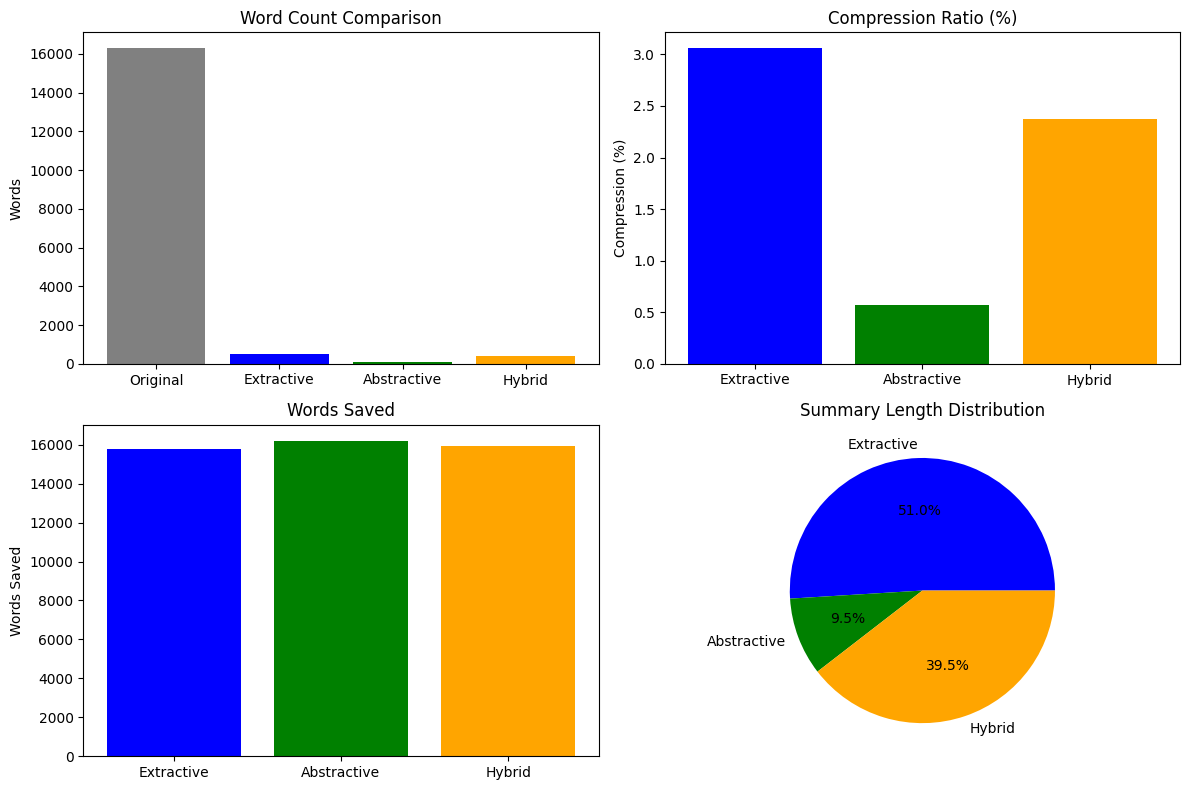

Plot saved to: outputs/analysis.png


<Figure size 640x480 with 0 Axes>

In [42]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Word counts
word_counts = [
    results['statistics']['original_words'],
    results['statistics']['extractive_words'],
    results['statistics']['abstractive_words'],
    results['statistics']['hybrid_words']
]
labels = ['Original', 'Extractive', 'Abstractive', 'Hybrid']
colors = ['gray', 'blue', 'green', 'orange']

axes[0, 0].bar(labels, word_counts, color=colors)
axes[0, 0].set_title('Word Count Comparison')
axes[0, 0].set_ylabel('Words')

# Compression ratios
compression_ratios = [
    results['statistics']['extractive_compression'],
    results['statistics']['abstractive_compression'],
    results['statistics']['hybrid_compression']
]

axes[0, 1].bar(['Extractive', 'Abstractive', 'Hybrid'], [r * 100 for r in compression_ratios], color=['blue', 'green', 'orange'])
axes[0, 1].set_title('Compression Ratio (%)')
axes[0, 1].set_ylabel('Compression (%)')

# Words saved
words_saved = [
    results['statistics']['original_words'] - results['statistics']['extractive_words'],
    results['statistics']['original_words'] - results['statistics']['abstractive_words'],
    results['statistics']['original_words'] - results['statistics']['hybrid_words']
]

axes[1, 0].bar(['Extractive', 'Abstractive', 'Hybrid'], words_saved, color=['blue', 'green', 'orange'])
axes[1, 0].set_title('Words Saved')
axes[1, 0].set_ylabel('Words Saved')

# Summary length comparison
axes[1, 1].pie([results['statistics']['extractive_words'], results['statistics']['abstractive_words'], results['statistics']['hybrid_words']],
               labels=['Extractive', 'Abstractive', 'Hybrid'], colors=['blue', 'green', 'orange'], autopct='%1.1f%%')
axes[1, 1].set_title('Summary Length Distribution')

plt.tight_layout()
plt.show()

# Save plot
plt.savefig(f"{config.OUTPUT_DIR}/analysis.png", dpi=300, bbox_inches='tight')
print(f"Plot saved to: {config.OUTPUT_DIR}/analysis.png")

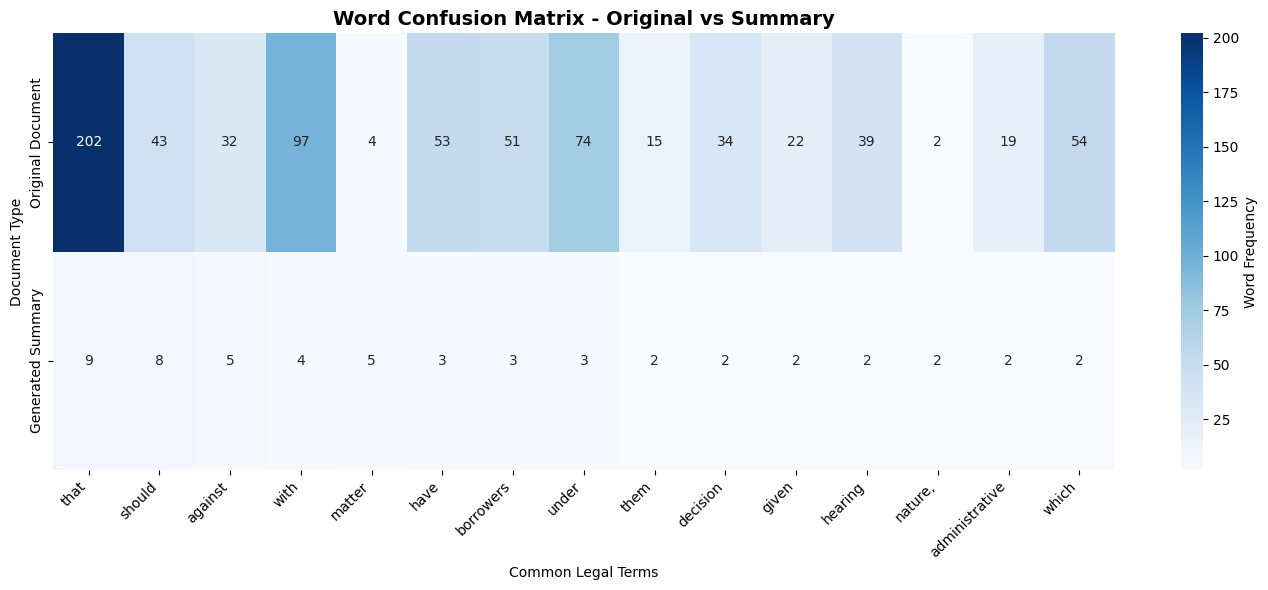

Confusion matrix saved to: outputs/word_confusion_matrix.png


<Figure size 640x480 with 0 Axes>

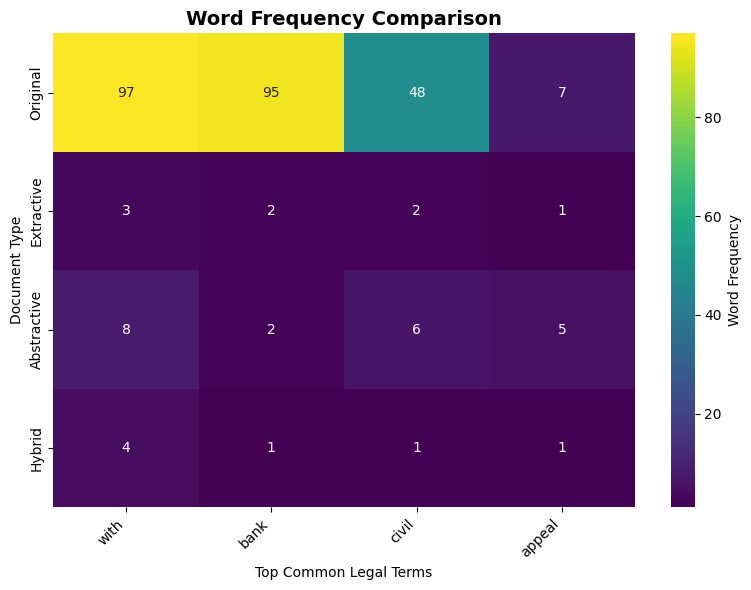

Summary comparison matrix saved to: outputs/summary_comparison_matrix.png


<Figure size 640x480 with 0 Axes>

In [43]:
from collections import Counter
from typing import Dict, Any # Added import for Dict and Any

def create_word_confusion_matrix(original_text: str, summary_text: str):
    """Create confusion matrix for word overlap between original and summary"""

    # Get word frequencies (filter words longer than 3 characters)
    original_words = Counter(word.lower() for word in original_text.split() if len(word) > 3)
    summary_words = Counter(word.lower() for word in summary_text.split() if len(word) > 3)

    # Get common words
    common_words = set(original_words.keys()) & set(summary_words.keys())

    # Select top 15 most frequent common words
    top_common = sorted(common_words, key=lambda x: min(original_words[x], summary_words[x]), reverse=True)[:15]

    # Create matrix data
    matrix_data = []
    for word in top_common:
        matrix_data.append([
            original_words[word],
            summary_words[word]
        ])

    matrix_data = np.array(matrix_data).T

    # Create heatmap
    plt.figure(figsize=(14, 6))
    sns.heatmap(matrix_data,
                xticklabels=top_common,
                yticklabels=['Original Document', 'Generated Summary'],
                annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Word Frequency'})

    plt.title('Word Confusion Matrix - Original vs Summary', fontsize=14, fontweight='bold')
    plt.xlabel('Common Legal Terms')
    plt.ylabel('Document Type')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Save confusion matrix
    plt.savefig(f"{config.OUTPUT_DIR}/word_confusion_matrix.png", dpi=300, bbox_inches='tight')
    print(f"Confusion matrix saved to: {config.OUTPUT_DIR}/word_confusion_matrix.png")

    return plt.gcf()

def create_summary_comparison_matrix(results: Dict[str, Any], num_words: int = 4):
    """Create a 4x4 matrix comparing word frequencies across original and all summaries."""

    original_text = results['original_text']
    extractive_summary = results['summaries']['extractive']
    abstractive_summary = results['summaries']['abstractive']
    hybrid_summary = results['summaries']['hybrid']

    # Get word frequencies for all texts
    original_words_count = Counter(word.lower() for word in original_text.split() if len(word) > 3)
    extractive_words_count = Counter(word.lower() for word in extractive_summary.split() if len(word) > 3)
    abstractive_words_count = Counter(word.lower() for word in abstractive_summary.split() if len(word) > 3)
    hybrid_words_count = Counter(word.lower() for word in hybrid_summary.split() if len(word) > 3)

    # Find overall common words
    all_words = set(original_words_count.keys()) \
                & set(extractive_words_count.keys()) \
                & set(abstractive_words_count.keys()) \
                & set(hybrid_words_count.keys())

    # Select top 'num_words' common words based on overall frequency
    top_common_words = sorted(list(all_words),
                              key=lambda x: original_words_count[x] + extractive_words_count[x] + abstractive_words_count[x] + hybrid_words_count[x],
                              reverse=True)[:num_words]

    # Create matrix data
    matrix_data = []
    for word in top_common_words:
        matrix_data.append([
            original_words_count[word],
            extractive_words_count[word],
            abstractive_words_count[word],
            hybrid_words_count[word]
        ])

    matrix_data = np.array(matrix_data).T # Transpose to get words as columns

    # Create heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix_data,
                xticklabels=top_common_words,
                yticklabels=['Original', 'Extractive', 'Abstractive', 'Hybrid'],
                annot=True, fmt='d', cmap='viridis',
                cbar_kws={'label': 'Word Frequency'})

    plt.title(f'Word Frequency Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Top Common Legal Terms')
    plt.ylabel('Document Type')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Save confusion matrix
    plt.savefig(f"{config.OUTPUT_DIR}/summary_comparison_matrix.png", dpi=300, bbox_inches='tight')
    print(f"Summary comparison matrix saved to: {config.OUTPUT_DIR}/summary_comparison_matrix.png")

    return plt.gcf()

# Create confusion matrix for hybrid summary
fig = create_word_confusion_matrix(results['original_text'], results['summaries']['hybrid'])

# Create 4x4 summary comparison matrix
fig_4x4 = create_summary_comparison_matrix(results, num_words=4)


In [44]:

print("\nSUMMARY:")
print("=" * 30)
print(f"Best summary: Hybrid ({results['statistics']['hybrid_words']} words)")
print(f"Compression: {results['statistics']['hybrid_compression']:.1%}")
print(f"\n{results['summaries']['hybrid']}")


SUMMARY:
Best summary: Hybrid (387 words)
Compression: 2.4%

The borrowers have placed reliance on Jah Developers (supra) to submit that debarring them from accessing institutional finance under Clause 8.12.1 of the Master Directions affects the fundamental right of the borrower to carry on business. We are of the opinion that keeping in view the nature, scope and consequences of direction under sub-rule (7) of Rule 633 of the Excise Manual, the principles of natural justice demand that a show-cause notice should be issued and an opportunity of hearing should be afforded to the person concerned before an order under the said Rule is made. If the statute conferring the power is silent with regard to the giving of a pre-decisional hearing, and the administrative decision taken by the authority involves civil consequences of a grave nature, and no full review or appeal on merits against that decision is provided, courts will be extremely reluctant to construe such a statute as excluding 

In [45]:
with open("/content/outputs/rsult.txt", 'r') as f:
  print(f.read())

The borrowers have placed reliance on Jah Developers (supra) to submit that debarring them from accessing institutional finance under Clause 8.12.1 of the Master Directions affects the fundamental right of the borrower to carry on business. We are of the opinion that keeping in view the nature, scope and consequences of direction under sub-rule (7) of Rule 633 of the Excise Manual, the principles of natural justice demand that a show-cause notice should be issued and an opportunity of hearing should be afforded to the person concerned before an order under the said Rule is made. If the statute conferring the power is silent with regard to the giving of a pre-decisional hearing, and the administrative decision taken by the authority involves civil consequences of a grave nature, and no full review or appeal on merits against that decision is provided, courts will be extremely reluctant to construe such a statute as excluding the duty of affording even a minimal hearing shorn of all its 